<a href="https://colab.research.google.com/github/DymaStar/DTA_2026/blob/main/ML/DS_230626_XGBoost_LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Градієнтний бустинг: XGBoost і LightGBM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

# ---------- Датасет: ВІДТІК (класифікація) ----------
m = 1500
tenure  = np.random.randint(1, 72, m)
monthly = np.random.normal(70, 25, m).clip(15, 150)
support = np.random.poisson(1.5, m)
age     = np.random.randint(18, 75, m)
contract = np.random.choice(["місячний", "річний", "дворічний"], m, p=[.5, .3, .2])
contract_risk = pd.Series({"місячний": .8, "річний": -.3, "дворічний": -.8})

risk = (-0.05*tenure + 0.02*monthly + 0.45*support - 0.01*age
        + contract_risk[contract].values + np.random.normal(0, .7, m))
prob = 1/(1+np.exp(-(risk-0.5)))
churn = (np.random.rand(m) < prob).astype(int)

cust = pd.DataFrame({
    "tenure": tenure, "monthly": monthly.round(1), "support": support,
    "age": age, "contract": contract, "churn": churn,
})

print("Частка відтоку:", f"{cust['churn'].mean():.1%}")
cust

Частка відтоку: 43.2%


,tenure,monthly,support,age,contract,churn
0,52,82.1,2,42,дворічний,1
1,15,59.5,5,69,дворічний,1
2,61,98.3,3,71,річний,0
3,21,63.1,0,41,місячний,1
4,24,104.6,5,74,місячний,1
...,...,...,...,...,...,...
1495,28,104.6,5,42,річний,1
1496,35,68.9,2,73,місячний,0
1497,61,118.3,0,48,річний,0
1498,54,67.5,3,54,місячний,0


## Pipelines

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score


X = cust[['tenure', 'monthly', 'support', 'age', 'contract']]
y = cust['churn']

num_cols = ['tenure', 'monthly', 'support', 'age']
cat_cols = ['contract']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pipe = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

pipe.fit(X_train, y_train)
print('Accuracy на тесті:', round(pipe.score(X_test, y_test), 3))

Accuracy на тесті: 0.74


In [4]:
cv = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
print(f'CV accuracy: {np.round(cv, 3)} | середнє: {cv.mean():.3f} ± {cv.std():.3f}')

CV accuracy: [0.767 0.747 0.683 0.74  0.747] | середнє: 0.737 ± 0.028


> Інтуїція: "команда, що виправляє помилки одне одного"


| | Random Forest | Градієнтний бустинг |
|---|---|---|
| Як будуються дерева | паралельно, незалежно | послідовно, кожне виправляє попередні |
| Логіка | усереднити багато думок | покроково зменшувати помилку |
| Точність на таблицях | висока | зазвичай **ще вища** |
| Ризик перенавчання | низький, прощає недогляд | вищий — потребує акуратного налаштування |

### Три головні гіперпараметри (решта - деталі)
- **`n_estimators`** - скільки дерев (скільки кроків виправлення).
- **`learning_rate`** - наскільки сильно кожне дерево коригує результат. Менше = обережніше й точніше, але треба більше дерев. Класичний компроміс: маленький `learning_rate` + багато дерев.
- **`max_depth`** - глибина кожного дерева. У бустингу тримають **невеликою** (3–6): дерева мають бути «слабкими», силу дає їх кількість.

### Крок 2. Перетворення категоріальної ознаки та синхронізація стовпців

Моделі Random Forest, XGBoost та LightGBM працюють лише з числовими даними, тому текстову ознаку `contract` потрібно перетворити у числовий формат.

Для цього використовуємо **One-Hot Encoding** (`pd.get_dummies()`), який створює окремий стовпець для кожного типу контракту.

Після перетворення додатково використовуємо `reindex()`, щоб тестова вибірка мала точно такі самі стовпці, як і навчальна. Це дозволяє уникнути помилок під час прогнозування, якщо в тестовій вибірці відсутній якийсь тип контракту.

Наприкінці виводимо перші рядки тестової вибірки для перевірки результату перетворення.

In [5]:
# Імпортуємо моделі та метрики,
# які будемо використовувати далі.

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# Перетворюємо категоріальну ознаку "contract"
# у набір числових стовпців (One-Hot Encoding).

X_tr = pd.get_dummies(
    X_train,
    columns=["contract"],
    dtype=int
)

# Для тестової вибірки виконуємо таке саме перетворення.
# reindex() гарантує, що набір стовпців буде
# повністю збігатися з навчальною вибіркою.
# Якщо якогось типу контракту немає,
# відповідний стовпець буде створено та заповнено нулями.

X_te = pd.get_dummies(
    X_test,
    columns=["contract"],
    dtype=int
).reindex(
    columns=X_tr.columns,
    fill_value=0
)

# Перевіряємо результат.
# Після перетворення замість одного текстового
# стовпця "contract" отримали три числові:

# contract_дворічний
# contract_місячний
# contract_річний

X_te.head()

,tenure,monthly,support,age,contract_дворічний,contract_місячний,contract_річний
599,62,52.6,1,50,0,0,1
1236,61,42.9,3,60,0,1,0
1452,49,77.1,0,18,0,1,0
334,5,80.5,2,26,1,0,0
123,42,16.1,3,52,0,1,0


# Висновок:
# Категоріальну ознаку "contract" успішно
# перетворено у числовий формат.
# Навчальна та тестова вибірки мають
# однаковий набір ознак і готові
# для навчання моделей бустингу.

### Крок 3. Порівняння моделей машинного навчання

На цьому етапі порівнюємо чотири моделі класифікації:

- **Logistic Regression** – базова лінійна модель.
- **Random Forest** – ансамбль незалежних дерев рішень.
- **XGBoost** – алгоритм градієнтного бустингу, де кожне нове дерево виправляє помилки попередніх.
- **LightGBM** – швидка реалізація градієнтного бустингу, оптимізована для роботи з великими наборами даних.

Для кожної моделі:
1. Навчаємо модель (крім Logistic Regression, яка вже була навчена раніше).
2. Отримуємо ймовірність належності до класу 1.
3. Обчислюємо метрики **Accuracy** та **ROC-AUC**.
4. Зберігаємо результати у таблицю для подальшого порівняння.

In [6]:
# Створюємо словник моделей,
# які будемо порівнювати.

models = {

    # Модель вже навчена у Pipeline
    "LogisticRegression": pipe,

    # Random Forest
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        random_state=RANDOM_STATE
    ),

    # XGBoost
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ),

    # LightGBM
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_STATE,
        verbose=-1
    )
}

# Список для збереження результатів усіх моделей
rows = []

# По черзі запускаємо кожну модель
for name, mdl in models.items():

    # LogisticRegression вже навчена,
    # тому лише отримуємо ймовірності.
    if name == "LogisticRegression":

        p = mdl.predict_proba(X_test)[:, 1]

    else:

        # Інші моделі потрібно навчити.
        mdl.fit(X_tr, y_train)

        # Отримуємо ймовірність класу 1.
        p = mdl.predict_proba(X_te)[:, 1]

    # Додаємо результати поточної моделі.
    rows.append({

        "model": name,

        # Accuracy
        "accuracy": round(
            accuracy_score(
                y_test,
                (p >= 0.5).astype(int)
            ),
            3
        ),

        # ROC-AUC
        "roc_auc": round(
            roc_auc_score(y_test, p),
            3
        )

    })

# Перетворюємо список словників у DataFrame
# для зручного порівняння моделей.
results = pd.DataFrame(rows)

results

,model,accuracy,roc_auc
0,LogisticRegression,0.740,0.821
1,RandomForest,0.773,0.827
2,XGBoost,0.757,0.798
3,LightGBM,0.737,0.782


# Висновок:
#
# Отримали таблицю з результатами всіх моделей.
#
# Accuracy показує,
# яку частку прогнозів модель зробила правильно.
#
# ROC-AUC показує,
# наскільки добре модель відокремлює
# один клас від іншого незалежно від порога 0.5.
#
# За отриманими значеннями можна визначити,
# яка модель працює найкраще на тестових даних.

### Крок 4. Аналіз важливості ознак (Feature Importance)

Після навчання моделі **XGBoost** можна оцінити, які ознаки найбільше впливають на прогноз.

Для цього використовуємо атрибут `feature_importances_`, який повертає числову оцінку важливості кожної ознаки.

Далі:
1. Створюємо таблицю з назвами ознак та їх важливістю.
2. Сортуємо ознаки за спаданням важливості.
3. Будуємо горизонтальну стовпчикову діаграму.
4. Аналізуємо, які характеристики найбільше впливають на рішення моделі.

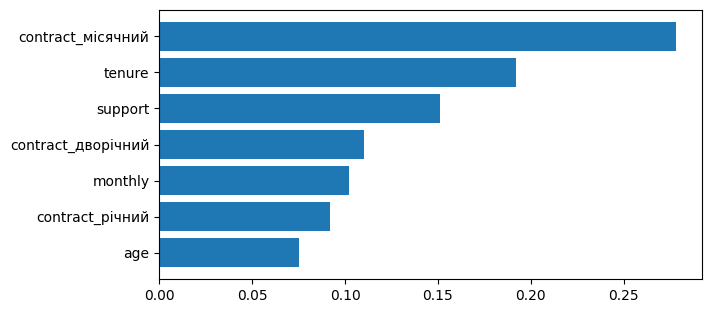

,feature,importance
5,contract_місячний,0.278
0,tenure,0.192
2,support,0.151
4,contract_дворічний,0.110
1,monthly,0.102
6,contract_річний,0.092
3,age,0.075


In [7]:
# Беремо вже навчену модель XGBoost
# зі словника моделей.

xgb = models["XGBoost"]


# Створюємо таблицю,
# яка містить назву кожної ознаки
# та її важливість для моделі.

imp = pd.DataFrame({

    "feature": X_tr.columns,
    "importance": xgb.feature_importances_.round(3)

})


# Сортуємо ознаки
# від найбільш важливих
# до найменш важливих.

imp = imp.sort_values(
    "importance",
    ascending=False
)


# Будуємо горизонтальну діаграму.

plt.figure(figsize=(7, 3.5))

plt.barh(
    imp["feature"],
    imp["importance"]
)

# Найважливіші ознаки
# відображаємо зверху.

plt.gca().invert_yaxis()

plt.show()


# Виводимо таблицю важливості ознак.

imp

# Висновок:
#
 Feature Importance показує,
які ознаки модель використовувала
 найчастіше та які найбільше
 впливали на прийняття рішення.

 Чим більше значення importance,
 тим сильніше ця ознака впливає
 на прогноз моделі XGBoost.

 Це допомагає зрозуміти,
 які характеристики клієнтів
є найважливішими для класифікації.

### Крок 4. Аналіз важливості ознак (Feature Importance)

Після навчання моделі **XGBoost** проаналізуємо, які ознаки найбільше впливають на її прогноз.

Для цього використовуємо атрибут `feature_importances_`, який містить оцінку внеску кожної ознаки у прийняття рішення моделлю.

За отриманими результатами будуємо горизонтальну стовпчикову діаграму та таблицю, відсортовану за спаданням важливості.

### Висновки

За результатами аналізу найбільший вплив на прогноз моделі має ознака **`contract_місячний`** (0.278). Це свідчить про те, що тип контракту є найважливішим фактором при прогнозуванні поведінки клієнта.

Другими за важливістю є **`tenure`** (0.192) — тривалість користування сервісом, та **`support`** (0.151) — кількість звернень до служби підтримки.

Менший внесок у прогноз роблять ознаки **`contract_дворічний`** (0.110), **`monthly`** (0.102), **`contract_річний`** (0.092) та **`age`** (0.075).

Отже, модель XGBoost приймає рішення насамперед на основі характеристик договору та історії користування сервісом, тоді як вік клієнта є найменш інформативною ознакою серед досліджуваних.

### Крок 5. Побудова ROC-кривих для порівняння моделей

Після навчання моделей порівняємо їхню якість за допомогою **ROC-кривих**.

ROC-крива (Receiver Operating Characteristic) показує, наскільки добре модель відокремлює один клас від іншого при різних порогах класифікації.

Для кожної моделі:
1. Отримуємо ймовірності належності до позитивного класу.
2. Обчислюємо точки ROC-кривої (`FPR` та `TPR`).
3. Обчислюємо площу під кривою (**AUC**).
4. Будуємо графік для порівняння всіх моделей.

Чим ближче ROC-крива до верхнього лівого кута, а значення **AUC** ближче до **1**, тим якісніше працює модель.

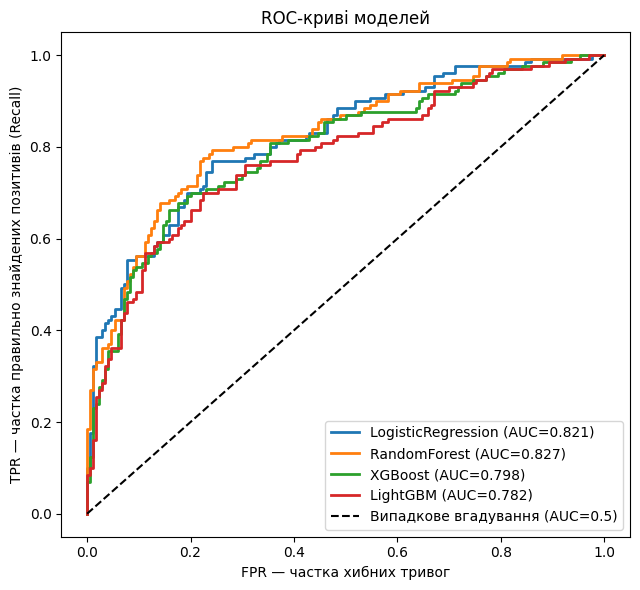

In [8]:
# Імпортуємо функції
# для побудови ROC-кривої
# та обчислення площі під нею (AUC).

from sklearn.metrics import roc_curve, auc


# Створюємо фігуру для графіка.
plt.figure(figsize=(6.5, 6))


# Будуємо ROC-криву
# для кожної моделі.

for name, mdl in models.items():

    # Logistic Regression вже навчена,
    # тому використовуємо X_test.
    if name == "LogisticRegression":
        p = mdl.predict_proba(X_test)[:, 1]

    # Для інших моделей
    # використовуємо підготовлені дані X_te.
    else:
        p = mdl.predict_proba(X_te)[:, 1]

    # Обчислюємо координати ROC-кривої.
    fpr, tpr, _ = roc_curve(y_test, p)

    # Будуємо ROC-криву.
    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{name} (AUC={auc(fpr, tpr):.3f})"
    )


# Лінія випадкового вгадування.
plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Випадкове вгадування (AUC=0.5)"
)

# Підписуємо осі.
plt.xlabel("FPR — частка хибних тривог")
plt.ylabel("TPR — частка правильно знайдених позитивів (Recall)")

# Заголовок графіка.
plt.title("ROC-криві моделей")

# Додаємо легенду.
plt.legend(loc="lower right")

# Автоматично підганяємо відступи.
plt.tight_layout()

# Відображаємо графік.
plt.show()

### Висновки

На графіку наведено ROC-криві чотирьох моделей класифікації. Чорна пунктирна лінія відповідає випадковому вгадуванню (AUC = 0.5). Усі досліджувані моделі розташовані значно вище цієї лінії, що свідчить про їхню здатність успішно розрізняти два класи.

Найкращий результат показала модель **Random Forest**, для якої площа під ROC-кривою становить **AUC = 0.827**. Її крива проходить трохи вище за інші, тому саме ця модель найкраще відокремлює позитивний клас від негативного.

Друге місце посіла **Logistic Regression** із показником **AUC = 0.821**. Незважаючи на простішу структуру, її якість майже не поступається Random Forest.

Модель **XGBoost** отримала **AUC = 0.798**, а **LightGBM** — **AUC = 0.782**. Обидві моделі демонструють хорошу якість класифікації, однак у цьому дослідженні вони поступаються Random Forest та Logistic Regression.

Отже, за критерієм **ROC-AUC** найкращою моделлю є **Random Forest**, оскільки вона має найбільше значення AUC та ROC-криву, що проходить вище за інші. Logistic Regression показала дуже близький результат, тоді як XGBoost і LightGBM мають дещо нижчу здатність розділяти класи.